In [97]:
import os
os.chdir("../dgl_ptm/")

import sys
import zarr
import time
import pickle
import dgl_ptm
import numpy as np
import networkx as nx

import osmnx as ox
import folium

import geopandas as gpd
import shapely
from shapely.geometry import Polygon, box, Point
import contextily as ctx

from tqdm.auto import tqdm
from dgl_ptm.util.utils import sample_distribution_tensor

os.environ["DGLBACKEND"] = "pytorch"
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from collections import Counter
import matplotlib
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": True, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

### Grid Construction

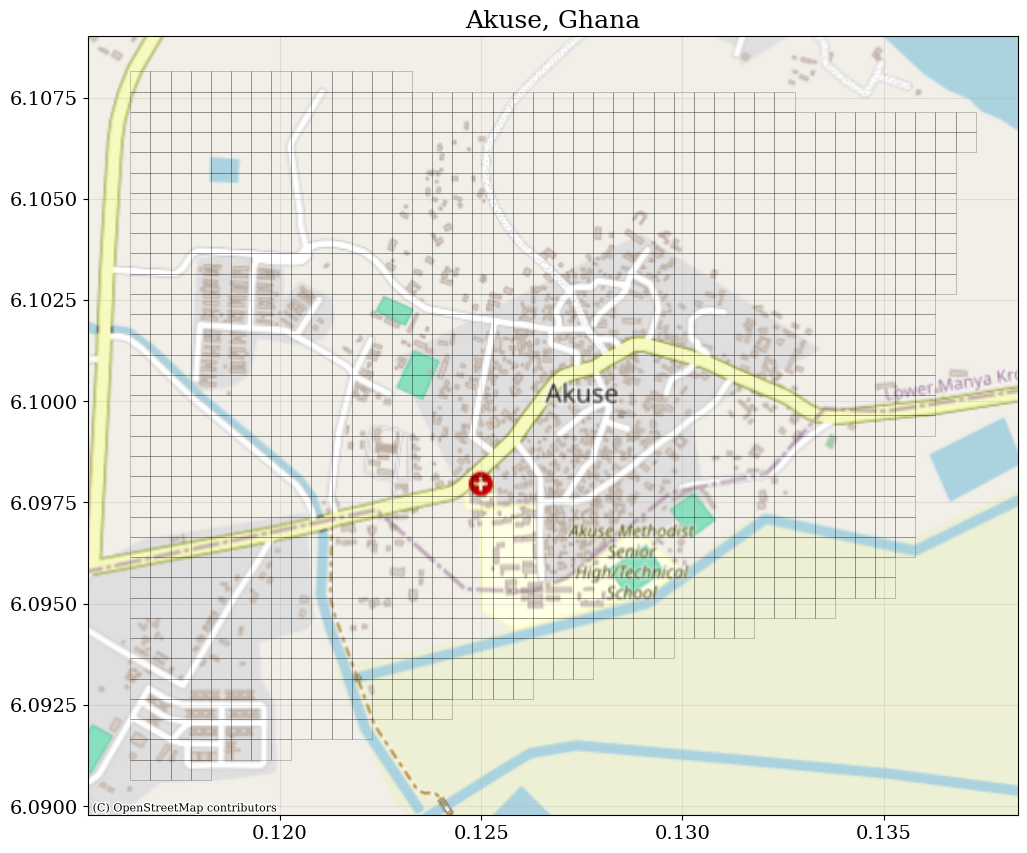

In [128]:
# Step 1: Manually Define Akuse's Boundary (Example Coordinates)
akuse_boundary_coords = [ (x[1],x[0]) for x in [
        (6.107983818842101, 0.11640835827890646),
        (6.106918939321614, 0.13688109260416578),
        (6.095601368066649, 0.13518748441180858),
        (6.090648307705022, 0.11628382826476255)
    ] 
]

boundary = Polygon(akuse_boundary_coords)
gdf = gpd.GeoDataFrame(geometry=[boundary], crs="EPSG:4326")  # WGS84 CRS

# Step 2: Create Grid within the Boundary
def create_grid(bounds, cell_size):
    """Generate a grid of square polygons within given bounds."""
    minx, miny, maxx, maxy = bounds
    x_coords = np.arange(minx, maxx, cell_size)
    y_coords = np.arange(miny, maxy, cell_size)
    grid_cells = []
    for x in x_coords:
        for y in y_coords:
            cell = box(x, y, x + cell_size, y + cell_size)
            if cell.intersects(boundary):  # Keep only cells inside Akuse
                grid_cells.append(cell)

    return gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:4326")

cell_size = 0.0005
grid = create_grid(boundary.bounds, cell_size)

# Step 3: Plot the Result
fig, ax = plt.subplots(figsize=(12, 12))
# gdf.plot(ax=ax, edgecolor="dodgerblue", facecolor="none", linewidth=2, label="Akuse Boundary")
grid.plot(ax=ax, edgecolor="k", facecolor="none", linewidth=0.5, alpha=0.3)
ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Akuse, Ghana")
plt.show()

### Population Density Grid

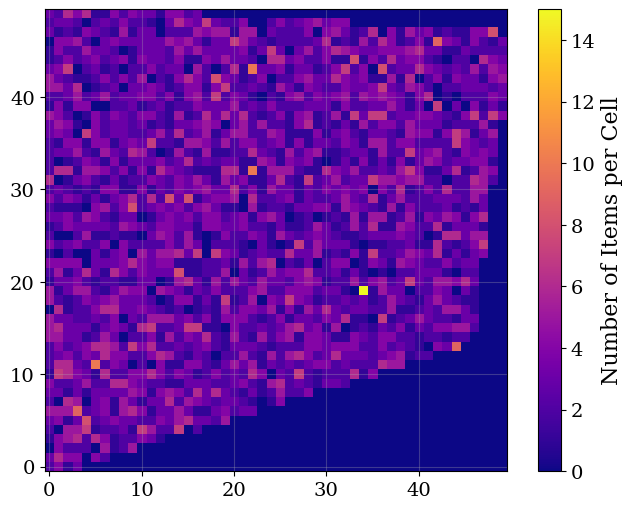

In [129]:
boundary = Polygon(akuse_boundary_coords)
gdf = gpd.GeoDataFrame(geometry=[boundary], crs="EPSG:4326")  

# Step 2: Define 50x50 Grid Over Bounding Box
rows, cols = 50, 50  # Define the shape (50x50)
minx, miny, maxx, maxy = boundary.bounds
x_step = (maxx - minx) / cols  # Cell width
y_step = (maxy - miny) / rows  # Cell height

# Step 3: Create Grid and Populate NumPy Array
grid_array = np.zeros((rows, cols, 1), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        x_start = minx + j * x_step
        y_start = miny + i * y_step
        cell = box(x_start, y_start, x_start + x_step, y_start + y_step)
        if cell.intersects(boundary):  # If cell intersects Akuse, set to 1
            grid_array[i, j, 0] = 1

valid_cells = np.argwhere(grid_array[:, :, 0] == 1)
num_valid_cells = len(valid_cells)
allocations = np.random.multinomial(6000, np.ones(num_valid_cells) / num_valid_cells)
distributed_grid = np.zeros((50, 50, 1), dtype=np.int32)
for i, (row, col) in enumerate(valid_cells):
    distributed_grid[row, col, 0] = allocations[i]

distributed_grid[19,34] = 15

plt.imshow(distributed_grid[:, :, 0], cmap="plasma", origin="lower")
plt.colorbar(label="Number of Items per Cell")
plt.show()

np.save("grid.npy", distributed_grid)

### Locations of Interest Grid

In [131]:
point = (6.100635676379143, 0.12736045405150456)
radius = 1000
tags = {"amenity": ["school", "place_of_worship"]}
gdf = ox.features_from_point(point, tags, dist=radius)

f = folium.Figure(width=750, height=400)
m = folium.Map(location=point, zoom_start=14).add_to(f)
for _, row in gdf.iterrows():
    folium.GeoJson(row['geometry']).add_to(m)

LOI = {}
for _, row in gdf.iterrows():
    amenity_type = row["amenity"]
    if amenity_type not in LOI:
        LOI[amenity_type] = []
    LOI[amenity_type].append((row["geometry"].centroid.x, row["geometry"].centroid.y))

m

In [132]:
# Step 2: Define 50x50 Grid Over Bounding Box
rows, cols = 50, 50  # Define the shape (50x50)
minx, miny, maxx, maxy = boundary.bounds
x_step = (maxx - minx) / cols  # Cell width
y_step = (maxy - miny) / rows  # Cell height

# Step 3: Create Grid and Populate NumPy Array
grid_array = np.zeros((rows, cols, 1), dtype=np.uint8)


for category, locations_of_interest in LOI.items():    
    # Step 1: Iterate through the grid and check if points fall inside
    location_to_cell = {}
    
    for lon, lat in locations_of_interest:
        point = Point(lon, lat)  # Convert to a Shapely point
        
        for i in range(50):  # Loop over rows
            for j in range(50):  # Loop over columns
                x_start = minx + j * x_step
                y_start = miny + i * y_step
                cell = box(x_start, y_start, x_start + x_step, y_start + y_step)  # Define the cell
                
                if cell.contains(point):  # Check if point is inside the cell
                    location_to_cell[(lon, lat)] = (i, j)  # Store row, col indices 
                    grid_array[i][j] = 1
                    break  # No need to check further once assigned

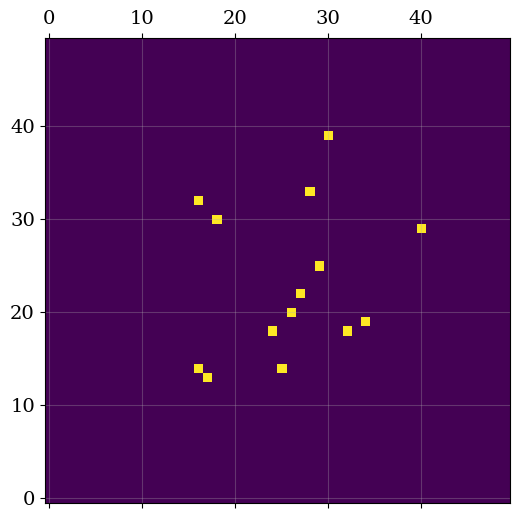

In [136]:
plt.matshow(grid_array, origin="lower")
plt.show()

### Model Creation

In [37]:
def create_model(seed=42, identifier="sveir_test", num_agents=10000, steps=100, new_node_edges=5):
    model = dgl_ptm.SVEIRModel(model_identifier=identifier)
    model.set_model_parameters(**{
        'number_agents': num_agents,
        'seed': seed,
        'spatial': True,
        'spatial_creation_args':{
            "method": "custom_import",
            "path": "grid.npy",
            "properties": {"population": 0}
        },
        'spatial_assignment_args':{'method':"property",'property':"population"},
        'initial_graph_type': 'barabasi-albert',
        'initial_graph_args': {'seed': seed, 'new_node_edges':new_node_edges},
        'device': 'cpu',
        'step_target': steps,
        'steering_parameters': {
            'npath':'./agent_data.zarr',
            'epath':'./edge_data',
            'ndata':[['compartments', 'num_infections', 'x', 'y'],['initial_only',[]]],
            'edata': None,
            'mode': 'w',
            'proximity_decay_rate': 0.05,
            'truncation_weight': 1e-10,
            'infection_probability': 0.3,
            'recovery_rate': 0.1,
            'vaccination_rate': 0.01,
            'vaccine_efficacy': 0.9,
            'exposure_period': 5,
            'initial_infected_proportion': 0.05,
            'step_type': 'seir'
        }
    })
    model.initialize_model()
    return model

In [52]:
asdf = torch.zeros((100, 6000, 2))

In [55]:
asdf[0][:,0] = m.graph.ndata["x"]
asdf[0][:,1] = m.graph.ndata["y"]

In [59]:
asdf[0]

tensor([[24.,  7.],
        [ 5.,  8.],
        [ 5., 12.],
        ...,
        [13.,  4.],
        [42., 43.],
        [13., 46.]])

In [3]:
# m = create_model(num_agents=15, seed=1)
# g = m.graph

# timea = time.time()

# num_nodes = g.num_nodes()
# src, dst = g.edges()
# edge_weights = torch.zeros((num_nodes, num_nodes))
# edge_weights[src, dst] = g.edata["weight"]

# # num nodes x num nodes matrix containing edges weights for infected nodes, otherwise 0
# susceptible_nodes = (g.ndata["compartments"] == 0).nonzero(as_tuple=True)[0]
# infected_weights = torch.where(g.ndata["compartments"].repeat(num_nodes, 1) == 3, edge_weights, 0)[susceptible_nodes]

# nonzero_weights = torch.where(infected_weights > 0)

# RNG = torch.rand((2, nonzero_weights[0].shape[0]))

# RNG1 = torch.zeros_like(infected_weights)
# RNG1[nonzero_weights] = RNG[0]
# RNG2 = torch.zeros_like(infected_weights)
# RNG2[nonzero_weights] = RNG[1]

# infection = (infected_weights > 0).type(torch.float32) * (RNG1 < infected_weights) * (RNG2 < m.steering_parameters["infection_probability"])
# infected_nodes = susceptible_nodes[torch.where(infection.sum(axis=1) > 0)]

# g.ndata["compartments"][infected_nodes] = 0
# g.ndata["exposure_time"][infected_nodes] = 0

# print(time.time()-timea)

### Profiling

In [3]:
agent_array = [1024, 4096, 16384, 131072, 1048576]
nne_array = [2, 4, 8]

T = {}
avg_deg = []

for nne in nne_array:
    T[nne] = {}
    for n_agents in tqdm(agent_array):
        model = create_model(num_agents=n_agents, new_node_edges=nne)
        if n_agents == agent_array[-1]:
            G = model.graph.to_networkx()
            avg_deg.append(round(sum(dict(G.degree()).values()) / n_agents))
        time_start = time.time()
        model.run()
        T[nne][n_agents] = time.time() - time_start

# with open("../DGL_testing/profiling_results.pickle", "wb") as f:
#     pickle.dump({
#         "avg_deg": avg_deg,
#         "time": T
#     }, f)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
with open("../DGL_testing/profiling_results.pickle", "rb") as f:
    profiling_result = pickle.load(f)

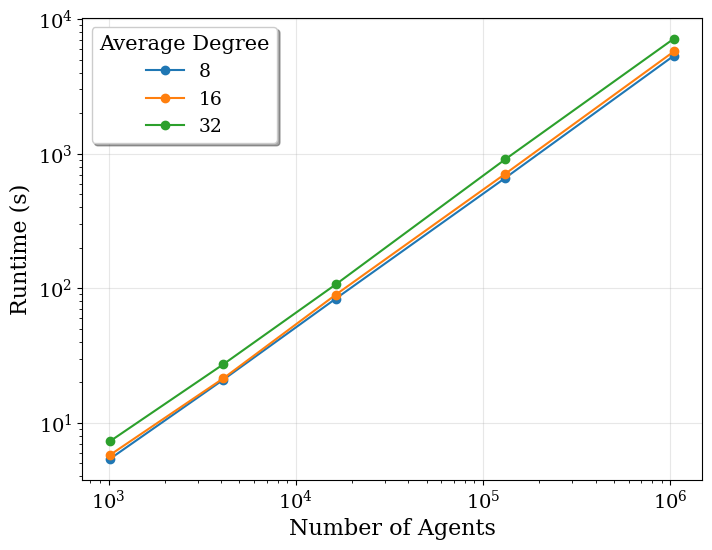

In [30]:
for i,nne in enumerate(profiling_result["time"]):
    plt.plot(
        list(profiling_result["time"][2].keys()),
        list(profiling_result["time"][nne].values()),
        label=profiling_result["avg_deg"][i],
        marker='o'
    )
plt.legend(shadow=True, title="Average Degree")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Agents")
plt.ylabel("Runtime (s)")
# plt.savefig("profiling.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# dist = []
# u, v = model.graph.edges()
# x_u = model.graph.ndata['x'][u]
# y_u = model.graph.ndata['y'][u]
# x_v = model.graph.ndata['x'][v]
# y_v = model.graph.ndata['y'][v]
# distance = torch.sqrt((x_u - x_v)**2 + (y_u - y_v)**2)
# plt.scatter(distance, model.graph.edata["weight"])
# plt.show()

# nx.draw(model.graph.to_networkx())

# plt.imshow(model.grid_environment.get_slice("population"), norm=LogNorm())
# plt.gca().invert_yaxixs()
# plt.scatter(model.graph.ndata['x'], model.graph.ndata['y'], c="red", s=10, alpha=0.3)
# plt.show()

### Results

In [4]:
model = create_model(num_agents=1000, new_node_edges=2)
model.run()

In [5]:
mapping = {
    "S":0,
    "V":1,
    "E":2,
    "I":3,
    "R":4
}
rev_mapping = {v:k for k,v in mapping.items()}

In [6]:
compartment_data = zarr.load('./sveir_test/agent_data.zarr/compartments')

In [7]:
SVEIR = {c:[] for c in mapping}
for col in range(compartment_data.shape[1]):
    time_step = compartment_data[:,col]
    counts = dict(Counter(time_step))
    for compartment, count in counts.items():
        SVEIR[rev_mapping[compartment]].append(count)

for k in SVEIR:
    while len(SVEIR[k]) < compartment_data.shape[1]:
        SVEIR[k].append(0)

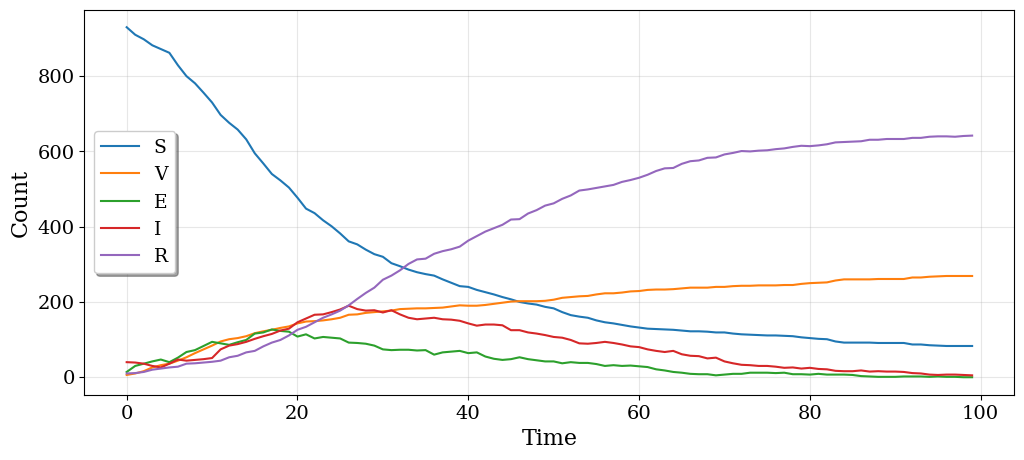

In [8]:
plt.figure(figsize=(12,5))

for c in SVEIR:
    plt.plot(SVEIR[c], label=c)

plt.legend(shadow=True)
plt.xlabel("Time")
plt.ylabel("Count")
plt.savefig("SVEIR_curves.pdf", bbox_inches="tight")
plt.show()